# Conditional GAN — Pixel Art Generation
comparison code only

This notebook trains a class-conditional DCGAN on 89,400 pixel art sprites at 16×16 resolution.

**Dataset**: same dataset as diffusion

## 1. Imports & Setup

In [1]:
!pip install -q clean-fid tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.4 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [3]:
import os, math, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.utils import make_grid

In [ ]:

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

### using gpu 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## checks to make sure gpu is being used
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Dataset Loading

In [5]:
DATA_ROOT = Path('/kaggle/input/datasets/ebrahimelgazar/pixel-art') 
sprites = np.load(DATA_ROOT / 'sprites.npy')         # (89400, 16, 16, 3) -- images: uint8
labels  = np.load(DATA_ROOT / 'sprites_labels.npy')  # (89400, 5) --  one-hot encoded labels

print(f'Sprites : {sprites.shape}  dtype={sprites.dtype}')
print(f'Labels  : {labels.shape}')

Sprites : (89400, 16, 16, 3)  dtype=uint8
Labels  : (89400, 5)


In [6]:
label_indices = np.argmax(labels, axis=1)  # (89400,) integer class

NUM_CLASSES = 5
CLASS_NAMES = [
    'Characters (no weapon)', 
    'Fruits & objects',
    'Large fruits',
    'Armors & arrows',
    'Characters (with weapon)',
]

print('Class distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = (label_indices == i).sum()
    print(f'  {i} - {name}: {count}')


Class distribution:
  0 - Characters (no weapon): 8000
  1 - Fruits & objects: 32400
  2 - Large fruits: 6000
  3 - Armors & arrows: 35000
  4 - Characters (with weapon): 8000


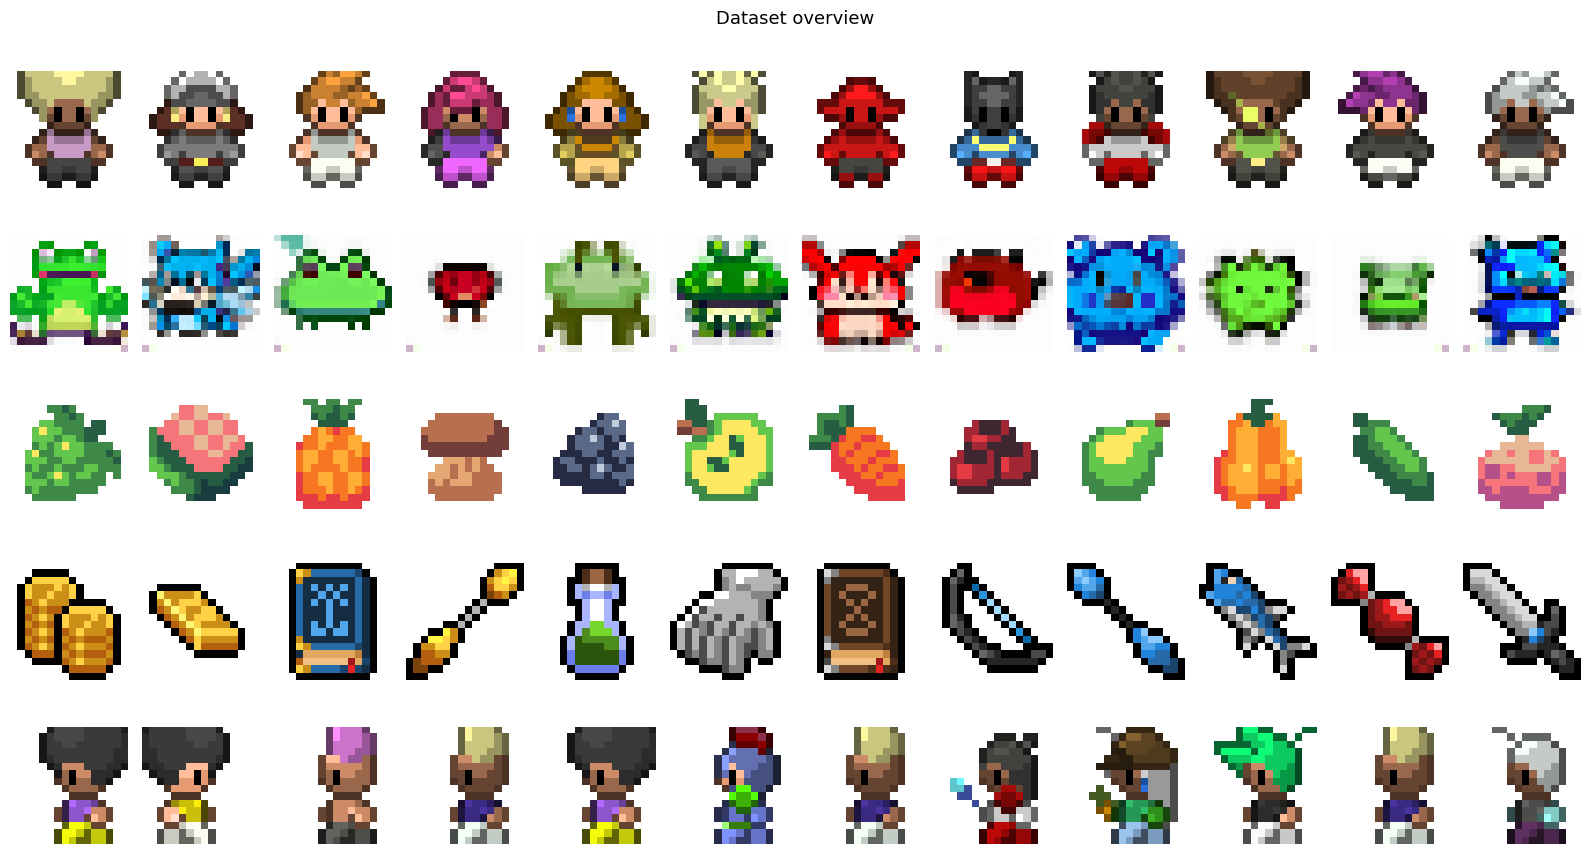

In [7]:
# just showing 12 per class  - viusalization
fig, axes = plt.subplots(NUM_CLASSES, 12, figsize=(16, NUM_CLASSES * 1.8))
fig.suptitle('Dataset overview', fontsize=13)

for cat in range(NUM_CLASSES):
    chosen = np.random.choice(np.where(label_indices == cat)[0], 12, replace=False)
    for col, idx in enumerate(chosen):
        axes[cat,col].imshow(sprites[idx])
        axes[cat,col].axis('off')
    # label on the left side
    axes[cat,0].set_ylabel(CLASS_NAMES[cat],fontsize=8,rotation=0,labelpad=110,va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/dataset_overview.png',dpi=120,bbox_inches='tight')
plt.show()

## 3. Preprocessing & DataLoader

In [8]:
IMG_SIZE    = 16
BATCH_SIZE  = 256
NUM_WORKERS = 2

class SpriteDataset(Dataset):
    """
    Wraps pre-loaded numpy sprites.
    Data augmentation: random horizontal flip + slight color jitter
    to reduce overfitting and improve generation diversity.
    """
    def __init__(self, sprites, label_indices, augment=False):
        self.sprites  = sprites
        self.labels   = label_indices
        self.augment  = augment

    def __len__(self): return len(self.sprites)

    def __getitem__(self, idx):
        img = self.sprites[idx].astype(np.float32) / 127.5 - 1.0
        img = torch.from_numpy(img).permute(2, 0, 1)  # (3,16,16)

        if self.augment:
            # random horizontal flip — 50% chance
            if random.random() > 0.5:
                img = torch.flip(img, dims=[2])
            # slight color jitter — prevents memorization
            img = (img + torch.randn_like(img) * 0.03).clamp(-1, 1)

        return img, int(self.labels[idx])

full_dataset  = SpriteDataset(sprites, label_indices, augment=False)
train_dataset_raw = SpriteDataset(sprites, label_indices, augment=True)

n_val   = int(0.1 * len(full_dataset))
n_train = len(full_dataset) - n_val

_, val_dataset = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
train_indices, _ = random_split(
    range(len(full_dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
from torch.utils.data import Subset
train_dataset = Subset(train_dataset_raw, train_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train : {n_train:,}  |  Val : {n_val:,}')
print(f'Train batches : {len(train_loader):,}')
print('Augmentation: horizontal flip + color jitter on train set')

train:80460,314 batches
val:8940


## 11. Conditional GAN 

In [ ]:
####GAN Config 
# Improvements over naive GAN:
# -Asymmetric LR (LR_G > LR_D) to prevent discriminator collapse
# -Spectral normalization on D for training stability
# -Label smoothing (0.9 instead of 1.0) to soften discriminator
# -ExponentialLR decay to gradually reduce learning rates

LATENT_DIM = 128   #increased from 64 for more generation diversity
GAN_EPOCHS = 200
LR_G       = 2e-4
LR_D       = 5e-5  #D learns slower than G
BETA1      = 0.5

print(f'GAN config: latent_dim={LATENT_DIM}, epochs={GAN_EPOCHS}')
print(f'LR_G={LR_G}, LR_D={LR_D} (asymmetric to prevent D collapse)')

GAN config: latent_dim=64, epochs=200
Dataset: 80,460 train images, 5 classes


In [ ]:
from torch.nn.utils import spectral_norm

#####Generator
# Takes noise vector + class embedding --> 16x16 RGB image
class Generator(nn.Module):
    def __init__(self, latent_dim=128, num_classes=5, base_ch=256):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, latent_dim)
        self.proj = nn.Sequential(
            nn.Linear(latent_dim * 2, base_ch * 4 * 4),
            nn.ReLU(True)
        )
        self.up = nn.Sequential(
            nn.ConvTranspose2d(base_ch, base_ch // 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch // 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(base_ch // 2, base_ch // 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_ch // 4),
            nn.ReLU(True),
            nn.Conv2d(base_ch // 4, 3, 3, 1, 1),
            nn.Tanh()
        )
        self.base_ch = base_ch

    def forward(self, z, c):
        c_emb = self.class_emb(c)
        x     = torch.cat([z, c_emb], dim=1)
        x     = self.proj(x)
        x     = x.view(-1, self.base_ch, 4, 4)
        return self.up(x)


#####Discriminator with Spectral Normalizationn
# Spectral norm constrains the Lipschitz constant of D,preventing it from becoming too powerful and crushing the generator.
class Discriminator(nn.Module):
    def __init__(self, num_classes=5, base_ch=32):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, 16 * 16)
        self.conv = nn.Sequential(
            spectral_norm(nn.Conv2d(3 + 1, base_ch, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, True),
            spectral_norm(nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, True),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            spectral_norm(nn.Linear(base_ch * 2 * 4 * 4, 1))
        )

    def forward(self, x, c):
        c_map = self.class_emb(c).view(-1, 1, 16, 16)
        x     = torch.cat([x, c_map], dim=1)
        x     = self.conv(x)
        return self.fc(x).squeeze(1)


G = Generator(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, base_ch=256).to(DEVICE)
D = Discriminator(num_classes=NUM_CLASSES, base_ch=32).to(DEVICE)

g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())
print(f'Generator     : {g_params/1e6:.2f}M parameters')
print(f'Discriminator : {d_params/1e6:.2f}M parameters (spectral norm)')
print(f'Total GAN     : {(g_params+d_params)/1e6:.2f}M parameters')

_z = torch.randn(4, LATENT_DIM).to(DEVICE)
_c = torch.randint(0, NUM_CLASSES, (4,)).to(DEVICE)
_x = torch.randn(4, 3, 16, 16).to(DEVICE)
assert G(_z, _c).shape == (4, 3, 16, 16)
assert D(_x, _c).shape == (4,)
print('Forward pass OK')

Generator     : 1.19M parameters
Discriminator : 0.04M parameters
Total GAN     : 1.22M parameters
Forward pass OK


In [ ]:
opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))
scheduler_G = torch.optim.lr_scheduler.ExponentialLR(opt_G, gamma=0.99)
scheduler_D = torch.optim.lr_scheduler.ExponentialLR(opt_D, gamma=0.99)
criterion   = nn.BCEWithLogitsLoss()

g_losses, d_losses = [], []
print(f'Training GAN for {GAN_EPOCHS} epochs...')
print('Improvements: spectral norm, label smoothing, asymmetric LR, ExponentialLR decay')
print('-' * 60)

for epoch in range(1, GAN_EPOCHS + 1):
    G.train(); D.train()
    g_loss_ep = d_loss_ep = 0.0

    for imgs, lbls in tqdm(train_loader, desc=f'GAN Epoch {epoch}/{GAN_EPOCHS}', leave=False):
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        B = imgs.size(0)

        # label smoothing: real=0.9 instead of 1.0
        # prevents D from becoming overconfident
        real_labels = torch.ones(B,  device=DEVICE) * 0.9
        fake_labels = torch.zeros(B, device=DEVICE)

        # train discriminator 
        opt_D.zero_grad()
        d_real    = D(imgs, lbls)
        loss_real = criterion(d_real, real_labels)
        z         = torch.randn(B, LATENT_DIM, device=DEVICE)
        fake      = G(z, lbls).detach()
        d_fake    = D(fake, lbls)
        loss_fake = criterion(d_fake, fake_labels)
        d_loss    = (loss_real + loss_fake) / 2
        d_loss.backward()
        opt_D.step()

        #train generator
        opt_G.zero_grad()
        z            = torch.randn(B, LATENT_DIM, device=DEVICE)
        fake         = G(z, lbls)
        d_fake_for_g = D(fake, lbls)
        g_loss       = criterion(d_fake_for_g, torch.ones(B, device=DEVICE))
        g_loss.backward()
        opt_G.step()

        g_loss_ep += g_loss.item()
        d_loss_ep += d_loss.item()

    g_losses.append(g_loss_ep / len(train_loader))
    d_losses.append(d_loss_ep / len(train_loader))
    scheduler_G.step()
    scheduler_D.step()

    if epoch % 50 == 0:
        print(f'Epoch {epoch:3d} | G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f} | LR_G: {scheduler_G.get_last_lr()[0]:.2e}')

print('GAN training complete!')

Training GAN for 200 epochs...
------------------------------------------------------------


Epoch  40 | G loss: 0.7984 | D loss: 0.6884 | LR_G: 1.34e-04


Epoch  80 | G loss: 0.8003 | D loss: 0.6891 | LR_G: 8.95e-05


Epoch 120 | G loss: 0.8038 | D loss: 0.6865 | LR_G: 5.99e-05


Epoch 160 | G loss: 0.7922 | D loss: 0.6886 | LR_G: 4.01e-05


Epoch 200 | G loss: 0.8138 | D loss: 0.6848 | LR_G: 2.68e-05
GAN training complete!


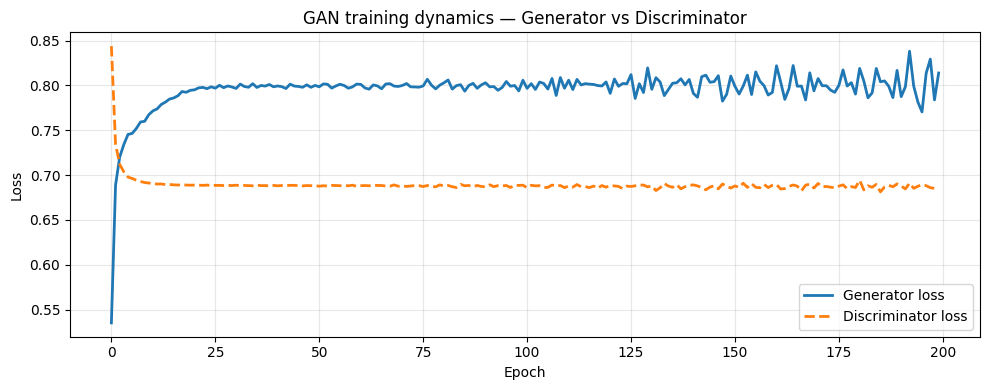

In [ ]:
# GAN training curves
# healthy GAN: G and D losses should oscillate around similar values
# if D loss is 0- discriminator winning, generator collapsed
# if G loss is 0- generator found a cheat, mode collapse likely

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g_losses, label='Generator loss',     linewidth=2)
ax.plot(d_losses, label='Discriminator loss', linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GAN training dynamics — Generator vs Discriminator')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/gan_training_curves.png', dpi=120)
plt.show()

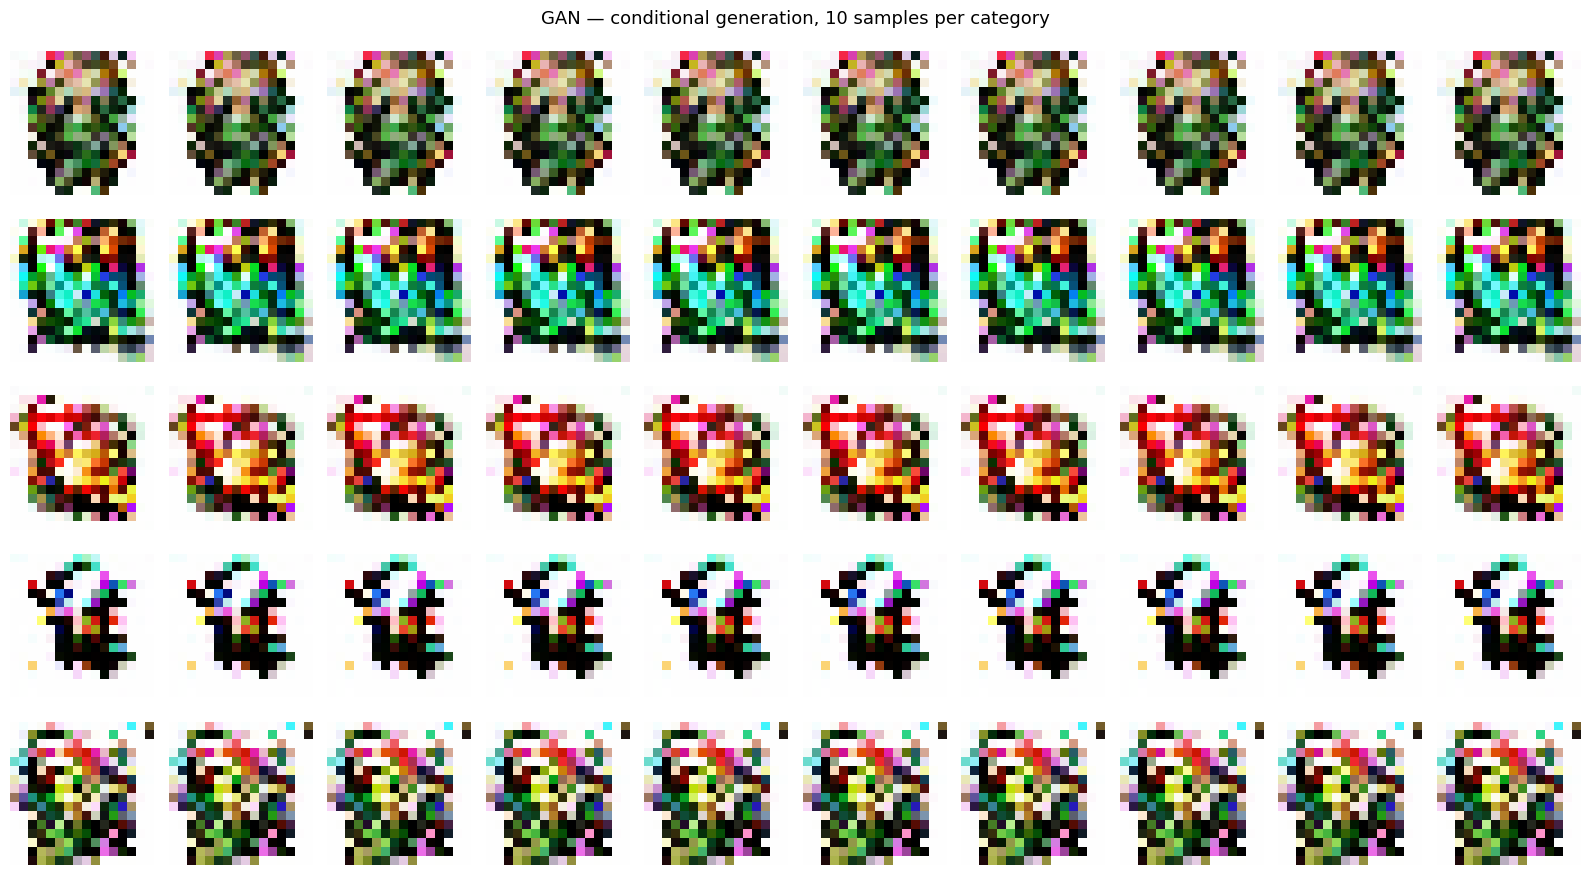

In [21]:
# ── GAN Sampling ──────────────────────────────────────────────────────────────
@torch.no_grad()
def sample_gan(G, class_label, n_samples=16):
    G.eval()
    z = torch.randn(n_samples, LATENT_DIM, device=DEVICE)
    c = torch.full((n_samples,), class_label, device=DEVICE, dtype=torch.long)
    return G(z, c)

# Generate 10 samples per category
N_GAN_SHOW = 10
fig, axes  = plt.subplots(NUM_CLASSES, N_GAN_SHOW,
                           figsize=(N_GAN_SHOW * 1.6, NUM_CLASSES * 1.8))
fig.suptitle('GAN — conditional generation, 10 samples per category', fontsize=13)

for cat in range(NUM_CLASSES):
    gen = sample_gan(G, class_label=cat, n_samples=N_GAN_SHOW)
    for col in range(N_GAN_SHOW):
        img = (gen[col].clamp(-1,1)*0.5+0.5).permute(1,2,0).cpu()
        axes[cat, col].imshow(img)
        axes[cat, col].axis('off')
    axes[cat, 0].set_ylabel(f'[{cat}] {CLASS_NAMES[cat]}',
                             fontsize=8, rotation=0, labelpad=120, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/gan_samples.png', dpi=120, bbox_inches='tight')
plt.show()